<a href="https://colab.research.google.com/github/dant56/google-collab-notebook/blob/main/3_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow.keras.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np

tf.random.set_seed(42)
np.random.seed(42)

print(tf.__version__)

2.20.0


In [ ]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = datasets.cifar10.load_data()
print(x_train_raw.shape)
print(x_test_raw.shape)
print(y_train_raw.shape)
print(y_test_raw.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000, 1)
(10000, 1)


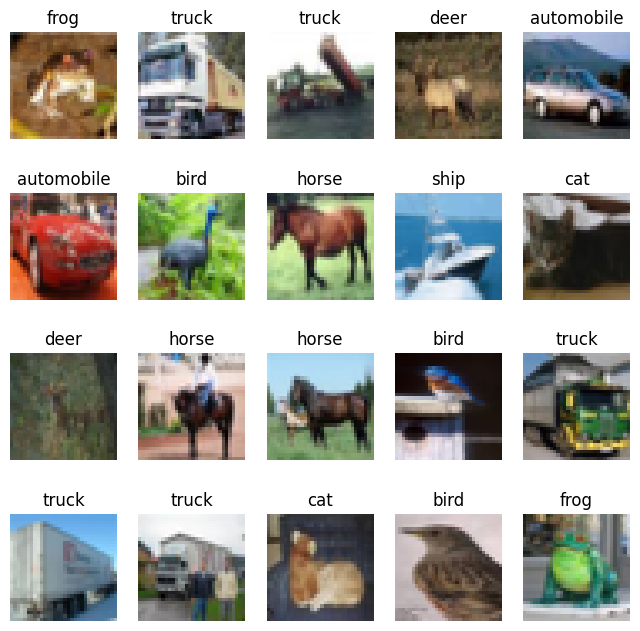

In [ ]:
plt.figure(figsize=(8, 8))
for i in range(20):
    plt.subplot(4, 5, i+1)   # 2 hàng, 5 cột
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

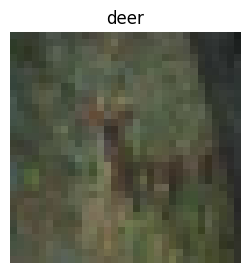

In [ ]:
index=10
plt.figure(figsize=(3, 3))
plt.imshow(x_train[index])
plt.title(class_names[y_train[index][0]])
plt.axis("off")
plt.show()

In [ ]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
x_train = x_train_raw.astype("float32")/255.0
x_test = x_test_raw.astype("float32")/255.0
y_train = y_train_raw.flatten()
y_test = y_test_raw.flatten()

print(x_train.shape, x_train.dtype)
print(x_test.shape, x_test.dtype)
print(y_train.shape, y_train.dtype)
print(y_test.shape, y_test.dtype)

(50000, 32, 32, 3) float32
(10000, 32, 32, 3) float32
(50000,) uint8
(10000,) uint8


In [ ]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ]
)

In [ ]:
def resudial_block(inputs, filters):
    x = layers.Conv2D(filters, (3,3),padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, (3,3),padding="same")(x)
    x = layers.BatchNormalization()(x)
    x=layers.Add()([x,inputs])
    x = layers.Activation("relu")(x)
    return x

In [ ]:
def build_model(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential(
        [
            #Input and Augmentation
            layers.Input(shape=input_shape),
            data_augmentation,
            # Block 1
            layers.Conv2D(
                32,
                (3, 3),
                padding="same",
                kernel_initializer="he_normal",
                input_shape=input_shape,
            ),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D((2, 2)),
            # Block 2
            layers.Conv2D(
                64, (3, 3), padding="same", kernel_initializer="he_normal"
            ),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D((2, 2)),
            # Block 3
            layers.Conv2D(
                128, (3, 3), padding="same", kernel_initializer="he_normal"
            ),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D((2, 2)),
            # Block 4
            layers.Conv2D(
                256, (3, 3), padding="same", kernel_initializer="he_normal"
            ),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            #Block 5
            layers.Conv2D(
                512, (3, 3), padding="same", kernel_initializer="he_normal"
            ),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            # Classifier Head
            layers.GlobalAveragePooling2D(),
            layers.Dense(64, activation="relu", kernel_initializer="he_normal"),
            layers.BatchNormalization(),
            layers.Dense(32, activation="relu", kernel_initializer="he_normal"),
            layers.Dropout(0.5),
            layers.Dense(num_classes, activation="softmax"),
        ],
        name="nu_cifar10",
        )

    return model
model= build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "nu_cifar10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,08

 Total params: 1,607,786 (6.13 MB)

 Trainable params: 1,605,802 (6.13 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
EPOCHS = 15
BATCH_SIZE = 128

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )
]

history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.3722 - loss: 1.7491 - val_accuracy: 0.4740 - val_loss: 1.4836
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.4987 - loss: 1.4196 - val_accuracy: 0.5031 - val_loss: 1.3451
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.5579 - loss: 1.2800 - val_accuracy: 0.6107 - val_loss: 1.0767
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.6001 - loss: 1.1907 - val_accuracy: 0.5836 - val_loss: 1.2687
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.6246 - loss: 1.1288 - val_accuracy: 0.6588 - val_loss: 0.9957
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.6485 - loss: 1.0673 - val_accuracy: 0.6363 - val_loss: 1.0529
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.6680 - loss: 1.0135 - val_accuracy: 0.6686 - val_loss: 0.9750
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.6796 - loss: 0.9816 - val_acc


---> Test Loss: 0.7467
---> Test Accuracy: 75.88%


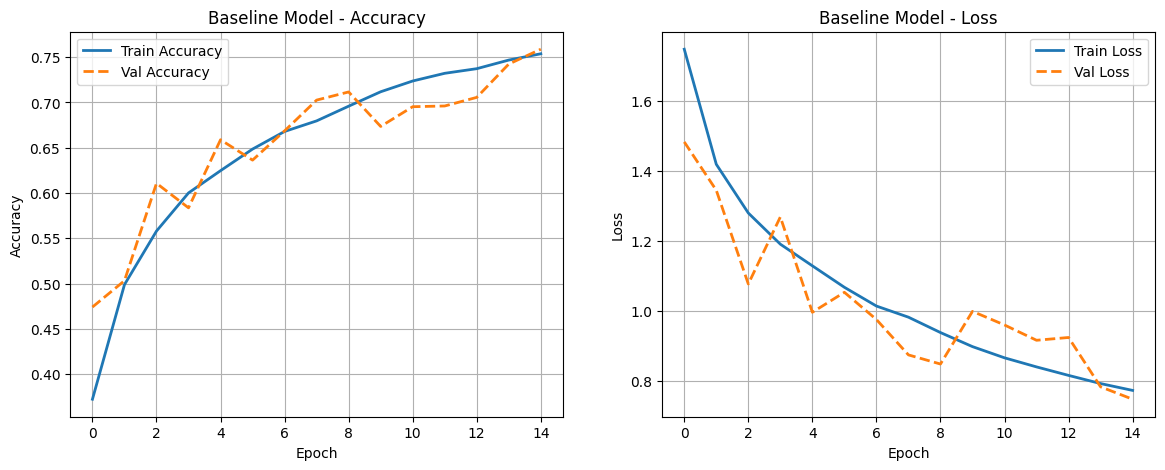

In [ ]:
# 1. Đánh giá trên tập Test
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n---> Test Loss: {test_loss:.4f}")
print(f"---> Test Accuracy: {test_acc * 100:.2f}%")

# 2. Vẽ biểu đồ Loss & Accuracy qua các Epochs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
ax1.plot(
    history.history["val_accuracy"],
    label="Val Accuracy",
    linewidth=2,
    linestyle="--",
)
ax1.set_title("Baseline Model - Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history["loss"], label="Train Loss", linewidth=2)
ax2.plot(
    history.history["val_loss"],
    label="Val Loss",
    linewidth=2,
    linestyle="--",
)
ax2.set_title("Baseline Model - Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.show()